🔎 What is Routing in LangGraph?

In LangGraph, routing is the mechanism that decides which node to go to next depending on the current state or some condition.

Normally, edges in a graph connect nodes in a fixed order (Node A → Node B → Node C).

With routing, instead of always going to a single fixed next node, the graph can dynamically decide:

Go to Node B if the answer looks correct

Or go to Node C if the answer looks incomplete

Or finish (END) if the work is already done

It’s like adding intelligence to the edges of your workflow graph.

⚖️ Analogy

👉 Imagine a hospital emergency room (ER):

Patient arrives at triage desk (Entry Node)

A nurse checks the patient (Routing Node):

If minor case, route to General Doctor (Node A)

If serious case, route to Specialist (Node B)

If critical, send directly to ICU (Node C)

If no treatment needed, Discharge (END)

Here, the triage desk = routing function in LangGraph.
It doesn’t do the treatment itself, but decides where to go next based on conditions.

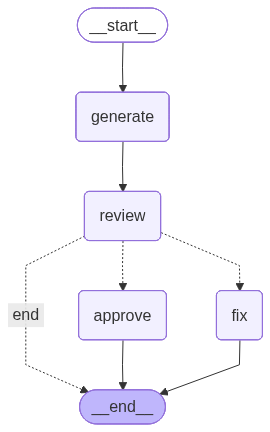

In [1]:
from langgraph.graph import StateGraph, END
from typing_extensions import TypedDict
from IPython.display import Image, display

# -------------------------------
# Define the State
# -------------------------------
class State(TypedDict):
    query: str
    draft: str
    final: str

# -------------------------------
# Node 1: Generate Draft
# -------------------------------
def generate_node(state: State):
    query = state["query"]
    return {"draft": f"Draft answer for: {query}"}

# -------------------------------
# Node 2: Review Draft
# -------------------------------
def review_node(state: State):
    draft = state["draft"]
    if "error" in draft.lower():
        return {"route": "fix"}   # Route to fix node
    elif "good" in draft.lower():
        return {"route": "approve"}  # Route to approval
    else:
        return {"route": "end"}   # Route to end

# -------------------------------
# Node 3: Fix Draft
# -------------------------------
def fix_node(state: State):
    return {"final": state["draft"].replace("error", "corrected")}

# -------------------------------
# Node 4: Approve Draft
# -------------------------------
def approve_node(state: State):
    return {"final": f"✅ Approved: {state['draft']}"}

# -------------------------------
# Build Graph with Routing
# -------------------------------
graph = StateGraph(State)

graph.add_node("generate", generate_node)
graph.add_node("review", review_node)
graph.add_node("fix", fix_node)
graph.add_node("approve", approve_node)

graph.set_entry_point("generate")
graph.add_edge("generate", "review")

# Routing edges
graph.add_conditional_edges(
    "review",
    lambda state: state["route"],   # Routing function
    {
        "fix": "fix",
        "approve": "approve",
        "end": END
    }
)

graph.add_edge("fix", END)
graph.add_edge("approve", END)

app = graph.compile()

# View
display(Image(app.get_graph().draw_mermaid_png()))



In [2]:
# -------------------------------
# Run Example
# -------------------------------
print(app.invoke({"query": "This has an error"}))
# → {'query': 'This has an error', 'draft': 'Draft answer for: This has an error', 'route': 'fix', 'final': 'Draft answer for: This has an corrected'}

print(app.invoke({"query": "This is good"}))
# → {'query': 'This is good', 'draft': 'Draft answer for: This is good', 'route': 'approve', 'final': '✅ Approved: Draft answer for: This is good'}

{'query': 'This has an error', 'draft': 'Draft answer for: This has an error', 'final': 'Draft answer for: This has an corrected'}
{'query': 'This is good', 'draft': 'Draft answer for: This is good', 'final': '✅ Approved: Draft answer for: This is good'}


🔑 Key Idea

add_conditional_edges() is where routing happens.

The function (lambda state: state["route"]) decides which edge to follow.

Output routes → mapped to nodes (fix, approve, end).

✅ Why Routing is Powerful

Enables branching logic in workflows.

Helps build complex agent flows (e.g., human approval, retrial loops, tool selection).

Reduces wasted compute by skipping unnecessary nodes.

👉 In short:
Routing in LangGraph = traffic signals in your workflow 🚦.
It directs the flow dynamically to the right lane (node) instead of always following a straight line.